# In-Sample Backtest of Selected Strategies

In this notebook, we analyze the in-sample performance of the top 4 intraday trading strategies identified in the previous optimization step.

Each strategy is defined by a specific **entry/exit time combination**, derived from a systematic grid search over all possible hourly pairs. The selection criterion used in the previous notebook was the **Sharpe ratio**, computed on the in-sample period (2018–2023).

In [1]:
import pandas as pd

import sys
import os

sys.path.append(os.path.dirname(os.getcwd()))

from src.backtest import run_backtest, compute_metrics, generate_position, backtest_strategies
from src.plotting import format_results_table, plot_equity_drawdown_grid

In [2]:
# Load EURUSD H1 dataset
df_full = pd.read_csv("../data/eurusd_h1.csv")

# Load the CSV file containing the top 4 strategies
# previously selected during the optimization phase
top4 = pd.read_csv("../data/top4_strategies.csv")

In [15]:
# Convert the selected strategies into a list of dictionaries
# Each dictionary contains the entry and exit hours
# for a single strategy configuration
strategies = top4[["entry_hour", "exit_hour"]].to_dict("records")

In [16]:
# sanity check
strategies

[{'entry hour': 1, 'exit hour': 2},
 {'entry hour': 0, 'exit hour': 2},
 {'entry hour': 1, 'exit hour': 3},
 {'entry hour': 0, 'exit hour': 3}]

In [17]:
# Convert timestamp column to datetime format
df_full["time"] = pd.to_datetime(df_full["time"])

# Set datetime as index for time-series operations
df_full = df_full.set_index("time")

In [18]:
# Reserve the most recent year as out-of-sample data.
# The remaining observations are used for research and strategy development.

split_date = "2024-01-01"

df = df_full[df_full.index < split_date].copy()

In [19]:
# Rename price column to a standard name used in the backtest engine
df = df.rename(columns={"close": "price"})

# Keep only relevant column for strategy/backtest
df = df[["price"]]

# Extract hour of day from datetime index to construct entry/exit trading signals
df["hour"] = df.index.hour

In [20]:
# Quick sanity check of the dataset structure

display(df.head())

df.info()

,price,hour
time,,
2018-04-06 08:00:00,1.22374,8
2018-04-06 09:00:00,1.22357,9
2018-04-06 10:00:00,1.22270,10
2018-04-06 11:00:00,1.22350,11
2018-04-06 12:00:00,1.22430,12


<class 'pandas.DataFrame'>
DatetimeIndex: 35654 entries, 2018-04-06 08:00:00 to 2023-12-29 23:00:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   35654 non-null  float64
 1   hour    35654 non-null  int32  
dtypes: float64(1), int32(1)
memory usage: 696.4 KB


In [21]:
# Run the backtest on all selected strategies using in-sample data
results_df, equity_curves = backtest_strategies(df, strategies)

In [22]:
# Display the results table with formatted values
format_results_table(results_df)

,Annualized Return,Annualized Volatility,Max Drawdown,Sharpe Ratio,Calmar Ratio
strategy,,,,,
1-2,3.49%,0.82%,-0.52%,4.24,6.64
0-2,3.90%,1.29%,-1.73%,3.03,2.25
1-3,3.11%,1.24%,-1.61%,2.51,1.92
0-3,3.52%,1.59%,-2.99%,2.22,1.18


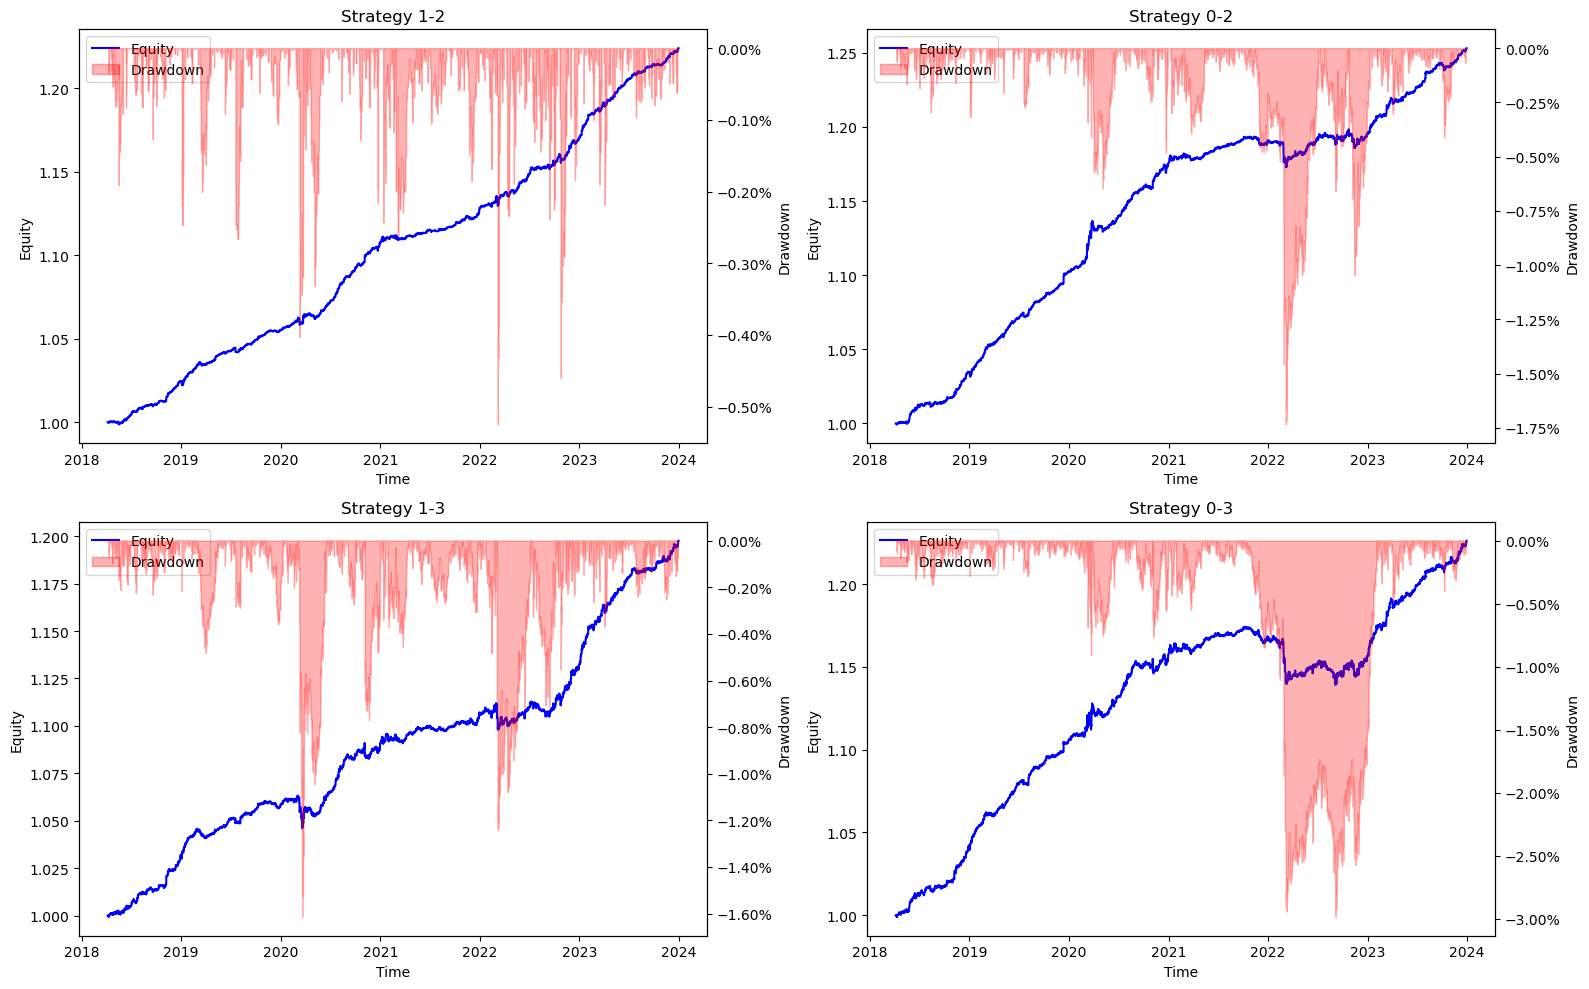

In [23]:
# Plot a grid of equity curves and their corresponding drawdowns
# for all strategies in the equity_curves collection
plot_equity_drawdown_grid(equity_curves)

# Conclusion

The in-sample results of the top 4 intraday strategies show generally strong and consistent performance over the evaluation period. However, a noticeable degradation in performance can be observed during the COVID-19 market regime, where volatility and structural breaks significantly impacted the stability of the strategies.

Outside of this period, the strategies demonstrate relatively stable equity curves and favorable risk-adjusted returns, suggesting that the observed intraday effect is not solely driven by short-term market noise.

The next step is to evaluate the robustness of these strategies on an **out-of-sample period**, in order to assess whether the observed intraday effects persist beyond the calibration dataset.